# Híbrido CNN + BiLSTM (end-to-end)

## La idea

Los modelos por época (XGBoost, MLP, CNN sola) tienen un techo: deciden la etapa de cada ventana de 30 s **de forma aislada**. Pero el sueño es una secuencia con estructura temporal fuerte (las etapas persisten, las transiciones siguen reglas). Este modelo ataca eso combinando dos arquitecturas en **un solo modelo**:

- una **CNN** que mira la señal cruda de cada época y la resume en un vector de features (morfología *intra-época*: ráfagas de movimiento, tendencia de la HR, tramos planos);
- una **BiLSTM** que lee la **secuencia** de esos vectores a lo largo de la noche y decide la etapa de cada época usando el contexto de las vecinas (dinámica *inter-época*).

Se entrena **end-to-end**: una sola loss se propaga por las dos partes, así la CNN aprende a extraer features que le sirven a la LSTM para decidir sobre la secuencia (no features "aisladas" por época).

## Reuso de código

No reimplementamos nada que ya existiera:
- **`src/CNN.py`** aporta los bloques convolucionales (el encoder intra-época).
- **`src/lstm.py`** aporta el `SleepStager` (que ya preveía un encoder enchufable), el padding, las métricas y los pesos de clase.
- Lo nuevo es sólo el pegamento: `sequence_data.py` (señal cruda por noche) y `cnn_lstm_hybrid.py` (el encoder que envuelve la CNN + el loop de entrenamiento).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

# --- Vacuna: forzamos el import de torch._dynamo temprano y en limpio. ---
# Si no, torch lo importa recién al crear el optimizer (dentro de train_hybrid) y,
# en un kernel de Jupyter con estado sucio, eso puede tirar
# "module 'sympy' has no attribute 'printing'". Importándolo acá se hace una sola
# vez y el resto del notebook lo reusa cacheado.
import torch
import torch._dynamo  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.sequence_data import build_night_sequences
from src.lstm import Config, STAGE_NAMES
from src.cnn_lstm_hybrid import train_hybrid

## 1. Datos por noche (señal cruda)

La LSTM procesa cada noche como una **secuencia ordenada de épocas** y no puede mezclar dos noches distintas (rompería la continuidad temporal). Para eso necesita saber **qué época pertenece a qué noche**.

`build_night_sequences` reprocesa la señal alineada (reusando la alineación de `data.py`) y guarda, por paciente, un `.npz` con:
- `X (N, 150, 4)` — la señal cruda de cada época (150 timesteps × 4 canales `[HR, mag_mean, mag_std, enmo_mean]`),
- `y (N,)` — la etapa del experto (0–4),
- `night_id (N,)` — **a qué noche pertenece cada época** (esto es lo nuevo).

### ¿En qué se diferencia de lo que ya está procesado?

| Ya en disco | Contenido | Para qué modelo |
|---|---|---|
| `epoch_features.csv` | features tabulares (122 por época) | MLP, XGBoost |
| `processed_data/*.npz` | señal cruda `(150×4)`, **sin `night_id`** | la CNN sola |
| `sequences/*.npz` | señal cruda `(150×4)` **+ `night_id`** | este híbrido |

La señal cruda se arma **exactamente igual** que para la CNN; la única diferencia es que ahora se guarda el `night_id`. No se puede reusar `processed_data` porque ahí las épocas están concatenadas sin marcar los bordes de noche, y esa información no se puede recuperar de los `.npz` viejos.

> Proceso pesado (~30 min, relee la señal cruda). Corré esta celda **una sola vez**; salteala si `sequences/` ya está poblada.

In [ ]:
build_night_sequences(output_dir="../data_extraction/sequences")

## 2. Entrenamiento end-to-end

`train_hybrid` arma el modelo híbrido y lo entrena. Qué hace por dentro:

**Arma el modelo.** El `CNNEpochEncoder` (que envuelve los bloques de `CNN.py`) se enchufa al `SleepStager` de `lstm.py`, formando la cadena `CNN → BiLSTM → capa lineal`.

**En cada paso (forward), las formas de los tensores:**

| Etapa | Forma | Qué pasa |
|---|---|---|
| Entrada | `[B, T, 150, 4]` | B noches, cada una con T épocas de señal `150×4` |
| CNN encoder | `[B, T, 128]` | cada época se resume en un vector de 128 |
| BiLSTM | `[B, T, 256]` | lee la secuencia (ida y vuelta) → contexto por época (128×2) |
| Capa lineal | `[B, T, 5]` | 5 logits (una etapa) por época |

Como las noches tienen distinto largo, se **padea** al máximo del batch y se usa `ignore_index` para que el relleno no cuente en la loss ni en las métricas.

**El gradiente ajusta las DOS partes a la vez** (CNN y LSTM): eso es *end-to-end*. No se entrena la CNN por un lado y la LSTM por otro — aprenden juntas con una sola loss.

**Alrededor del loop:**
- Split **por paciente** (train/val/test disjuntos, sin fuga de información).
- **Loss ponderada por clase** (desbalance N2 ≫ N1) + **clipping de gradiente** (estabiliza el entrenamiento de la LSTM).
- Cada epoch evalúa en validación y **guarda el mejor modelo según el Kappa de validación** (la métrica que nos importa, no la loss).
- Al final carga el mejor checkpoint y reporta el **test**.

Devuelve `(model, history, test_m)`: el modelo entrenado, el historial por epoch (para las curvas) y las métricas de test.

> Es más lento que los modelos por época: la CNN corre sobre todas las épocas de cada noche en cada paso. Conviene GPU.

In [2]:
cfg = Config(
    hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True,
    batch_size=8, lr=1e-3, epochs=40, use_class_weights=True,
    ckpt_path="../data_extraction/best_cnn_lstm.pt",
)

model, history, test_m = train_hybrid(cfg, sequences_dir="../data_extraction/sequences")

sujetos -> train 33 | val 7 | test 7
Epoch   1 | loss 1.5912 | val kappa 0.0026 | macroF1 0.0809 | acc 0.1181
Epoch   2 | loss 1.5868 | val kappa 0.0591 | macroF1 0.2088 | acc 0.2567
Epoch   3 | loss 1.5705 | val kappa 0.0804 | macroF1 0.2276 | acc 0.2826
Epoch   4 | loss 1.5384 | val kappa 0.1079 | macroF1 0.2436 | acc 0.2984
Epoch   5 | loss 1.4958 | val kappa 0.1184 | macroF1 0.2713 | acc 0.3487
Epoch   6 | loss 1.4512 | val kappa 0.0280 | macroF1 0.1405 | acc 0.2301
Epoch   7 | loss 1.4117 | val kappa 0.0804 | macroF1 0.2153 | acc 0.2811
Epoch   8 | loss 1.3705 | val kappa 0.0831 | macroF1 0.2342 | acc 0.3319
Epoch   9 | loss 1.3441 | val kappa 0.1363 | macroF1 0.3098 | acc 0.3202
Epoch  10 | loss 1.3156 | val kappa 0.0323 | macroF1 0.1398 | acc 0.1844
Epoch  11 | loss 1.3701 | val kappa 0.0092 | macroF1 0.0532 | acc 0.0982
Epoch  12 | loss 1.2759 | val kappa 0.0000 | macroF1 0.0319 | acc 0.0866
Epoch  13 | loss 1.2602 | val kappa 0.2075 | macroF1 0.3779 | acc 0.3841
Epoch  14 | lo

### Curvas de entrenamiento

A la izquierda, la loss de train por epoch. A la derecha, las métricas de **validación** (kappa, macro-F1, accuracy): sirven para ver si el modelo generaliza y en qué epoch quedó el mejor checkpoint (el de mayor kappa).

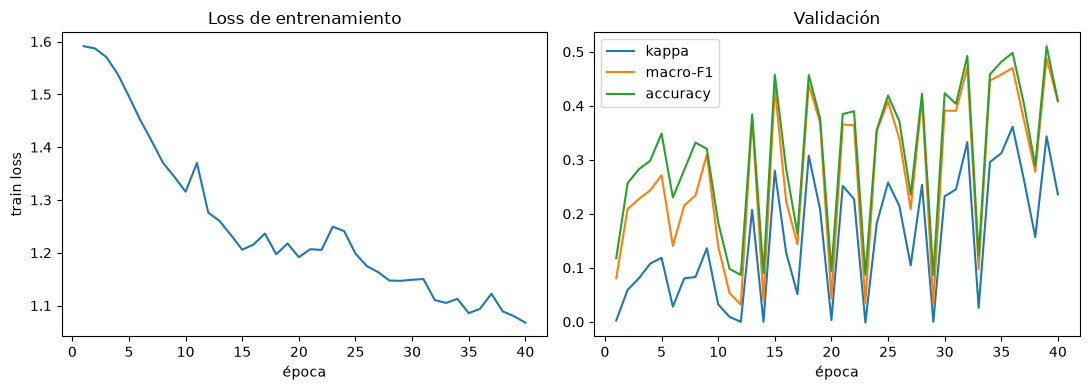

In [3]:
ep = [h['epoch'] for h in history]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [h['train_loss'] for h in history])
ax[0].set_xlabel('época'); ax[0].set_ylabel('train loss'); ax[0].set_title('Loss de entrenamiento')
ax[1].plot(ep, [h['kappa'] for h in history], label='kappa')
ax[1].plot(ep, [h['macro_f1'] for h in history], label='macro-F1')
ax[1].plot(ep, [h['accuracy'] for h in history], label='accuracy')
ax[1].set_xlabel('época'); ax[1].set_title('Validación'); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Métricas en test

`train_hybrid` ya reporta el test con el mejor checkpoint (5 clases y la vista colapsada a 4: Wake/Light/Deep/REM). Acá lo mostramos ordenado — **Accuracy**, **F1-macro** y **Cohen's Kappa** — más la **matriz de confusión** a 5 clases, que muestra con qué se confunde cada etapa (típicamente N1 se mezcla con N2/Wake).

Al ser un modelo que sí aprovecha el contexto temporal, esperamos un **kappa superior** al de los modelos por época (MLP/XGBoost/CNN sola).

In [4]:
print(f"Accuracy       : {test_m['accuracy']:.3f}")
print(f"F1-score macro : {test_m['macro_f1']:.3f}")
print(f"Cohen's Kappa  : {test_m['kappa']:.3f}")
print()
print("Matriz de confusión (5 clases):")
print(pd.DataFrame(test_m['confusion'], index=STAGE_NAMES, columns=STAGE_NAMES))

Accuracy       : 0.478
F1-score macro : 0.470
Cohen's Kappa  : 0.351

Matriz de confusión (5 clases):
      Wake    N1    N2    N3   REM
Wake  2093   592    57   142   482
N1     562  1092   135   151   839
N2     872  1624  2878  2317  3791
N3     640   226   348  4096   345
REM    220  1207   358   486  3953
